## houseing eda 

In [16]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('housing.csv')

In [18]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [19]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [20]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [21]:
df.shape

(20640, 10)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [23]:
df["total_bedrooms"].fillna(df["total_bedrooms"].mean()
                            .astype(int), inplace=True)

In [24]:
change_type = [
    "total_bedrooms",
    "population",
    "households",
    "total_rooms",
    "housing_median_age"
]

df[change_type] = df[change_type].astype(int)

df["ocean_proximity"] = df["ocean_proximity"].astype("category")

In [25]:
df.dtypes

longitude              float64
latitude               float64
housing_median_age       int64
total_rooms              int64
total_bedrooms           int64
population               int64
households               int64
median_income          float64
median_house_value     float64
ocean_proximity       category
dtype: object

In [26]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.861822,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266601,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.describe(include="category")

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


# univariate analysis

In [29]:
df["population"].mean()

np.float64(1425.4767441860465)

In [30]:
df["population"].median()

np.float64(1166.0)

In [31]:
df["population"].mode()

0    891
Name: population, dtype: int64

In [ ]:
df(numaric_only=True)["population"].min()-df["population"].max()

np.int64(-35679)

In [ ]:
df.max(numaric_only=True)-df.min(numaric_only=True)
df.var(numaric_only=True)
df.std(numaric_only=True)
df["population"].skew()
df["population"].kurt()


np.float64(1282470.4572332578)

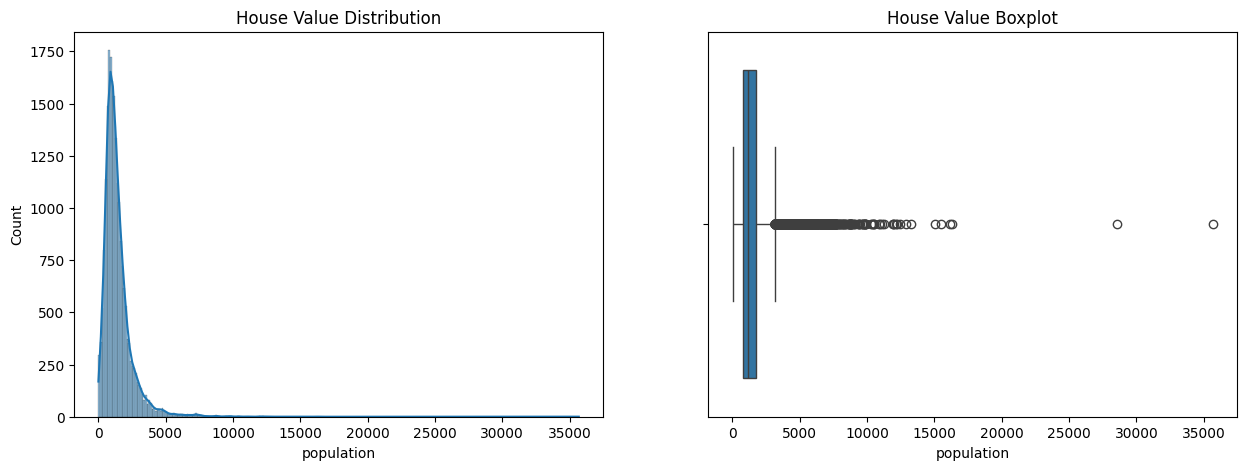

In [34]:
fig, axcs=plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    df["population"],
    kde=True,
    ax=axcs[0])

axcs[0].set_title("House Value Distribution")

sns.boxplot(
    x=df["population"],
    ax=axcs[1]
)

axcs[1].set_title("House Value Boxplot")

plt.show()




In [35]:
df["population"].skew()
df["population"].kurt()


np.float64(73.55311639416514)

In [36]:
df["ocean_proximity"].value_counts()

df["ocean_proximity"].nunique()

5

C:\Users\ayush\AppData\Local\Temp\ipykernel_11304\837033689.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)


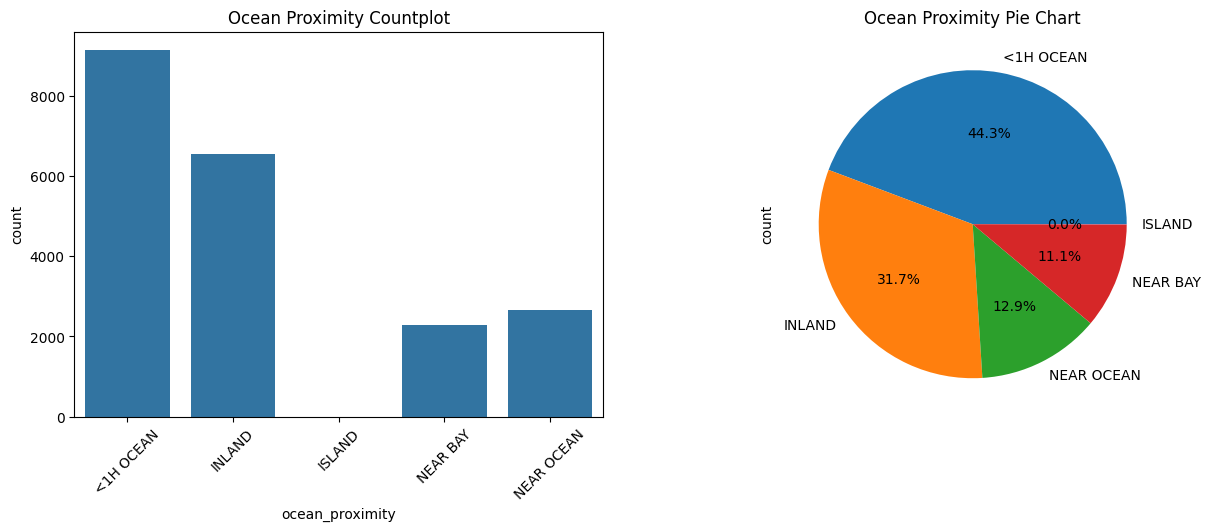

In [37]:
fig, ax = plt.subplots(1,2, figsize= (15,5))

sns.countplot(
    x=df["ocean_proximity"],
    ax=ax[0]
)

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

df["ocean_proximity"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax[1]
)
ax[0].set_title("Ocean Proximity Countplot")

ax[1].set_title("Ocean Proximity Pie Chart")

plt.show()



# bivariate analysis


### numarical vs numarical

In [38]:
df [["median_income",
    "median_house_value"]].corr()

,median_income,median_house_value
median_income,1.000000,0.688075
median_house_value,0.688075,1.000000


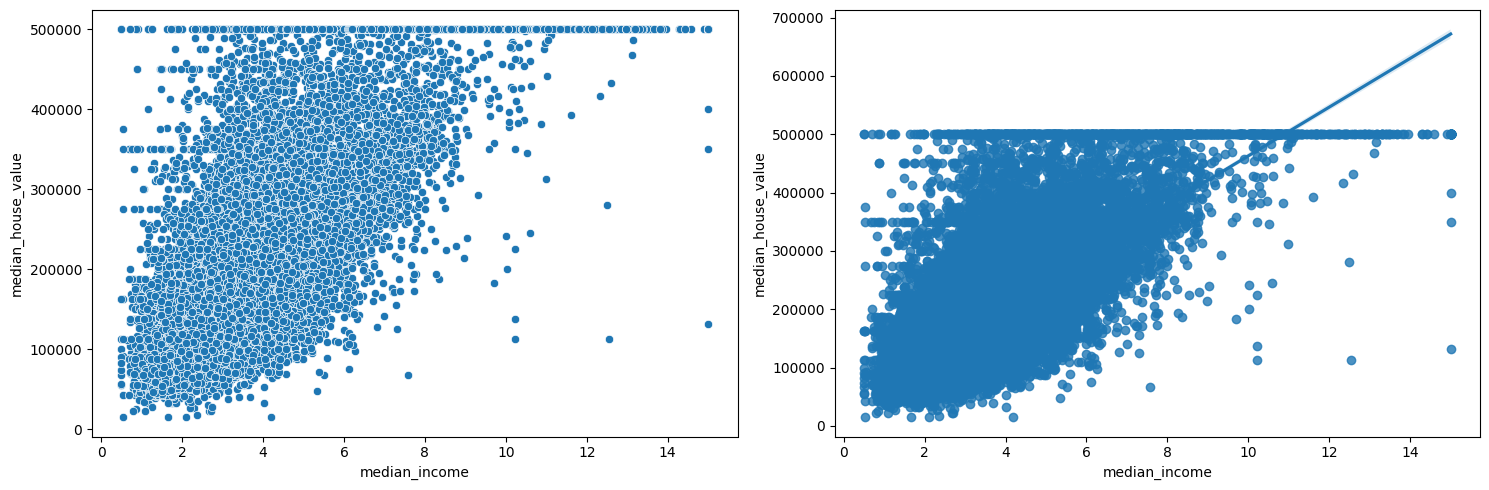

In [39]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.scatterplot(
    x=df["median_income"],
    y=df["median_house_value"],
    ax=ax[0]
)

sns.regplot(
    x=df["median_income"],
    y=df["median_house_value"],
    ax=ax[1]
)

plt.tight_layout()
plt.show()

### numarical vs catagorical

In [40]:
df.groupby(
    "ocean_proximity",observed=True
)["median_house_value"].mean()

ocean_proximity
<1H OCEAN     240084.285464
INLAND        124805.392001
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
Name: median_house_value, dtype: float64

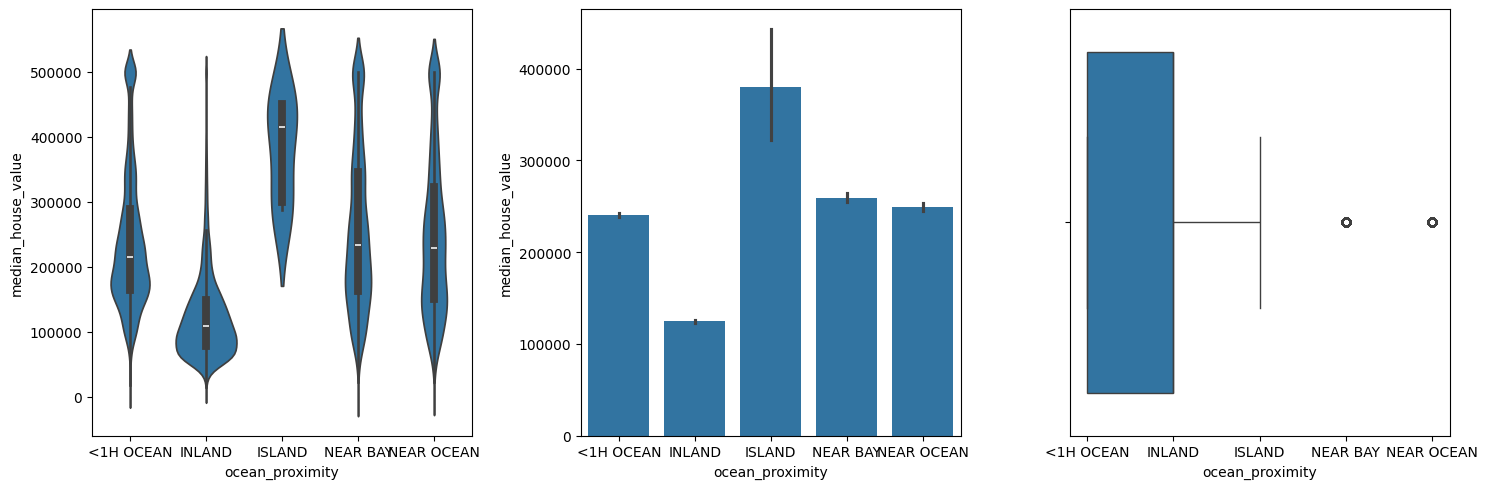

In [41]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

sns.violinplot(
    x=df["ocean_proximity"],
    y=df["median_house_value"],
    ax=ax[0])

sns.barplot(
    x=df["ocean_proximity"],
    y=df["median_house_value"],
    ax=ax[1]
)

sns.boxplot(
    x=df["ocean_proximity"])

plt.tight_layout()
plt.show()

### multivariate

In [42]:
corr = df.corr(
    numeric_only=True
)

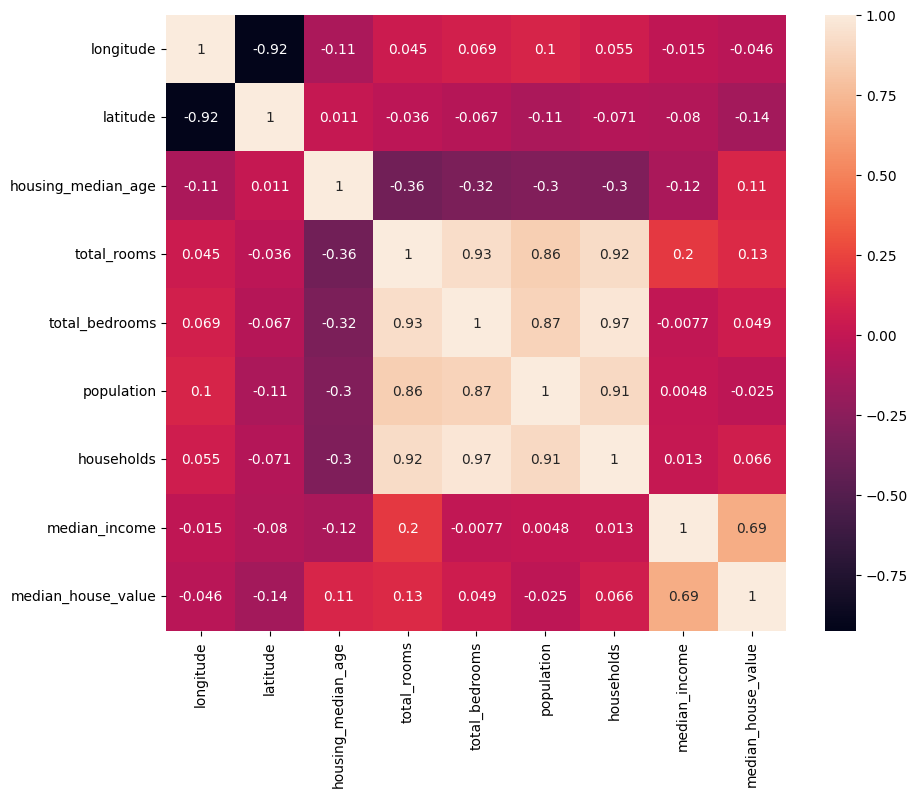

In [43]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True
)

plt.show()

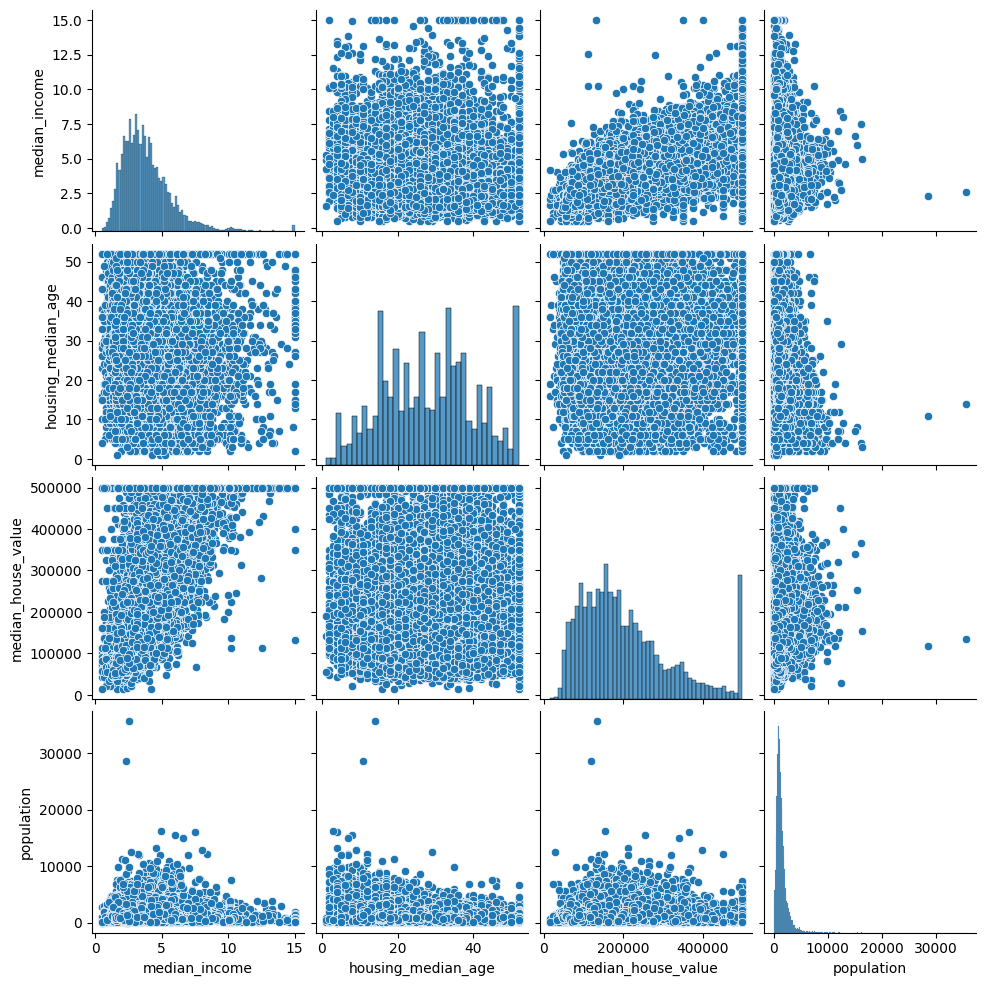

In [44]:
sns.pairplot(df[["median_income","housing_median_age","median_house_value","population"]])
plt.show()

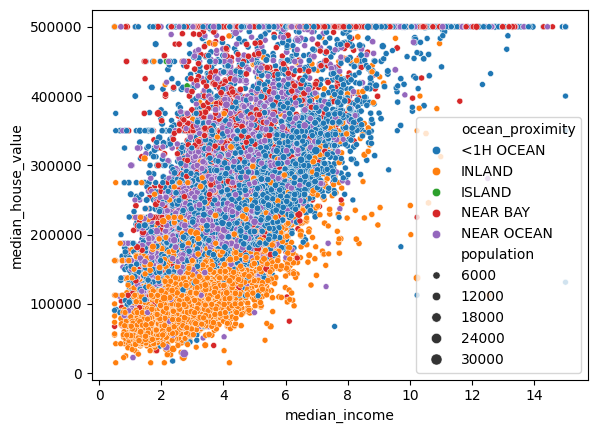

In [45]:
sns.scatterplot(
    x=df["median_income"],
    y=df["median_house_value"],hue=df["ocean_proximity"],size=df["population"]
)

plt.show()

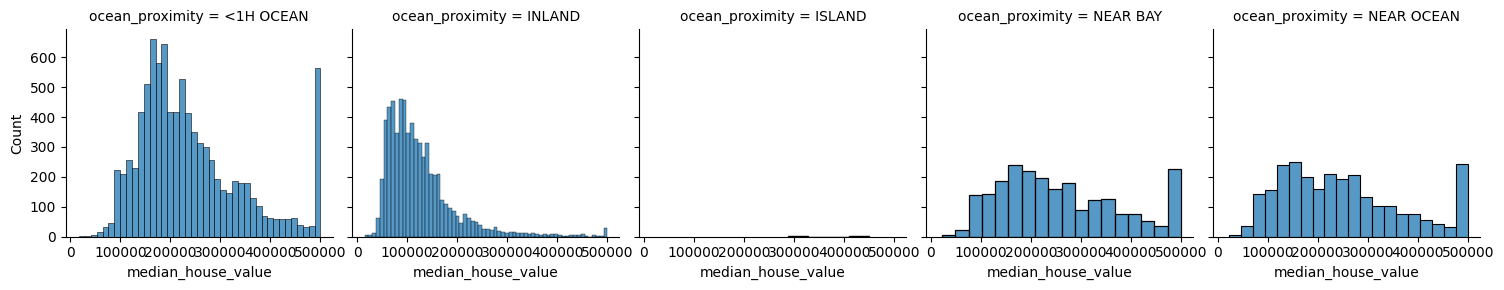

In [46]:
g = sns.FacetGrid(df, col="ocean_proximity")
g.map(sns.histplot, "median_house_value") 
plt.show()